# Introudction + providing necessary tools
In this laboratory you will learn about classification problems and how they can be approached using a category of tree-based models. In particular, you will use a decision tree from scikit-learn. You will see it in action with different datasets and understand its points of strength and weaknesses. Then, you will implement your own version of a random forest, starting from scikit-learn’s decision trees.  

# 1.2.1 Wine dataset
The Wine dataset is a famous dataset available on the UCI ML repository. The data is the result of a chemical analysis of wines grown in the same region in Italy, but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines. From these 13 constituents (features), your goal is to predict the target class (the cultivars). You can either download the dataset from UCI, or you can get it directly from scikit-learn.

```python
from sklearn.datasets import load_wine
dataset = load_wine ()
X = dataset [ " data " ]
y = dataset [ " target " ]
f e a t u r e _ n a m e s = dataset [ " f e a t u r e _ n a m e s " ]
```

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, ParameterGrid, KFold
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import numpy as np

import matplotlib.pyplot as plt
import graphviz

from IPython.display import display

import pandas as pd

In [ ]:
dataset = load_wine ()
x = dataset["data"]             # ARRAY of lists (numbers)
y = dataset["target"]           # ARRAY (0,1,2 I think they correspond to classes)
feature_names = dataset ["feature_names"]

print(x)
print(feature_names)            # ARRAY of strings, all the attributes
# print(type(dataset))

> ### How many records are available?
> ### Are there missing values?
> ### How many elements does each class contain?

In [ ]:
# How many records are available?
print('How many records are available?')
print(x.shape)
print(y.shape)
# 178

print('----------------------')

# Are there missing values?
print('Are there missing values?')
x_df = pd.DataFrame(x, columns = feature_names)
x_df['class'] = y
DF = x_df

count_null = DF.notnull().count()
info = DF.info()
display(count_null)
display(info)
# No mising values

print('----------------------')

# How many elements does each class contain?
print('How many elements does each class contain?')
print(DF['class'].value_counts())


> # 2. Create a DecisionTreeClassifier object with the default configuration (i.e. without passing any parameters to the constructor). Train the classifier using your X and y.

### Example of Creating and Training a Decision Tree Classifier
```python
# Step 1: Import necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 2: Load a sample dataset (Iris dataset for demonstration)
data = load_iris()
X = data.data  # features
y = data.target  # target labels

# Step 3: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Create a DecisionTreeClassifier object with the default configuration
clf = DecisionTreeClassifier()  # Default parameters (no hyperparameters passed)

# Step 5: Train the classifier using the training data
clf.fit(X_train, y_train)

# Step 6: Make predictions on the test data
y_pred = clf.predict(X_test)

# Step 7: Evaluate the model's performance using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the decision tree classifier: {accuracy:.4f}")
```

#### 1.	Import necessary libraries

#### 2.	Load the dataset

#### 3.	Split the dataset
- train_test_split splits the dataset into training and testing sets. Here, 80% of the data is used for training, and 20% is used for testing.

#### 4.	Create a Decision Tree Classifier:
- clf = DecisionTreeClassifier() creates an instance of the decision tree classifier with the default parameters. You can customize the tree’s behavior by passing various parameters like max_depth, min_samples_split, etc. But here, we’re using the default configuration.

#### 5. Train the model:
- clf.fit(X_train, y_train) trains the decision tree classifier using the training data (X_train, y_train).

#### 6.	Make predictions:
- After training, we use clf.predict(X_test) to predict the labels for the test data (X_test).

#### 7.	Evaluate the model:
- We use accuracy_score(y_test, y_pred) to compute the accuracy of the classifier by comparing the predicted labels (y_pred) with the actual labels (y_test).

In [ ]:
# load DS

# split the dataset into train and test, using 80% for training and 20% for testing, using the seed 42
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

# create the decision tree model
clf = DecisionTreeClassifier()

# train the model with training data x_train, y_train
clf.fit(x_train, y_train)

# make predictions based on what the model learned on the training data
predictions = clf.predict(x_test)

# evaluate the goodness of the predictions comparing them to the actual labels y_test --> accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy of the model: {accuracy}")

### Now that you have created a tree, you can visualize it. Sklearn offers two functions to visualize decision trees:
- The first one, **plot_tree()**:
Plots the tree in a matplotlib-based, interactive window.  

- An alternative way is using **export_graphviz()**.  
This function exports the tree as a DOT file. DOT is a language for describing graph (and, as a consequence, trees). From the DOT code, you can generate the resulting visual representation either using specific Python libraries, or by using any online tools (such as Webgraphviz).  

We recommend using the latter approach, where you paste the string returned by export_graphviz (which is the DOT file) directly into Webgraphviz.  
If, instead, you would rather run it locally, you can install pydot (Python package) and graphviz (a graph visualization software). Then, you can plot a graph with the following code snippet:
```python
import pydot
from IPython . display import Image
from sklearn . tree import e x p o r t _ g r a p h v i z
clf = D e c i s i o n T r e e C l a s s i f i e r (...)
...
# here , features is a list of names , one for each feature
# this makes the resulting tree v i s u a l i z a t i o n more c o m p r e h e n s i b l e
dot_code = e x p o r t _ g r a p h v i z ( clf , f e a t u r e _ n a m e s = features )
graph = pydot . g r a p h _ f r o m _ d o t _ d a t a ( dot_code )
Image ( graph [0]. c rea te _p ng () )
```

# export_graphviz()
```python
# Export the decision tree to DOT format
dot_data = export_graphviz(classification_model, out_file=None, 
                           feature_names=,  
                           class_names=,  
                           filled=True, rounded=True,  
                           special_characters=True)

# Use Graphviz to visualize the tree
graph = graphviz.Source(dot_data)  
graph.render("decision_tree", format="png")  # Saves the visualization as a PNG file
graph.view()  # Opens the image using the default viewer
```

In [ ]:
x = dataset["data"]             # ARRAY of lists (numbers)
y = dataset["target"]           # ARRAY (0,1,2 I think they correspond to classes)
feature_names = dataset ["feature_names"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

clf = DecisionTreeClassifier()

clf.fit(x_train, y_train)

predictions = clf.predict(x_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy of the model: {accuracy}")


# plot the decision tree
# dot_data = export_graphviz(clf, out_file=None, 
#                            # feature_names = feature_names,             NOPE
#                            # class_names= y,                            NOPE
#                            filled=True, rounded=True,  
#                            special_characters=True)
# You cannot use feature_names = feature_names and class_names= y

# Why use data.feature_names and data.target_names instead of feature_names and y?
# The data object that you get when you load datasets using scikit-learn (like load_iris()) is a special object called a Bunch.
# A Bunch is a dictionary-like object with attributes that contain the data and metadata related to the dataset.
# When you load a dataset using load_iris(), scikit-learn automatically gives you a dictionary-like object that holds:
# 	•	data: The actual input features (a NumPy array of shape (n_samples, n_features)).
# 	•	target: The target labels (the class labels, usually integers).
# 	•	feature_names: A list of strings that are the names of the features (e.g., "sepal length (cm)", "sepal width (cm)").
# 	•	target_names: A list of strings that are the names of the classes (e.g., "setosa", "versicolor", "virginica").

# plot the decision tree
dot_data = export_graphviz(clf, out_file=None, 
                           feature_names = dataset.feature_names,
                           class_names= dataset.target_names,
                           filled=True, rounded=True,  
                           special_characters=True)

# Use Graphviz to visualize the tree
graph = graphviz.Source(dot_data)  
graph.render("decision_tree", format="png")  # Saves the visualization as a PNG file
graph.view()  # Opens the image using the default viewer

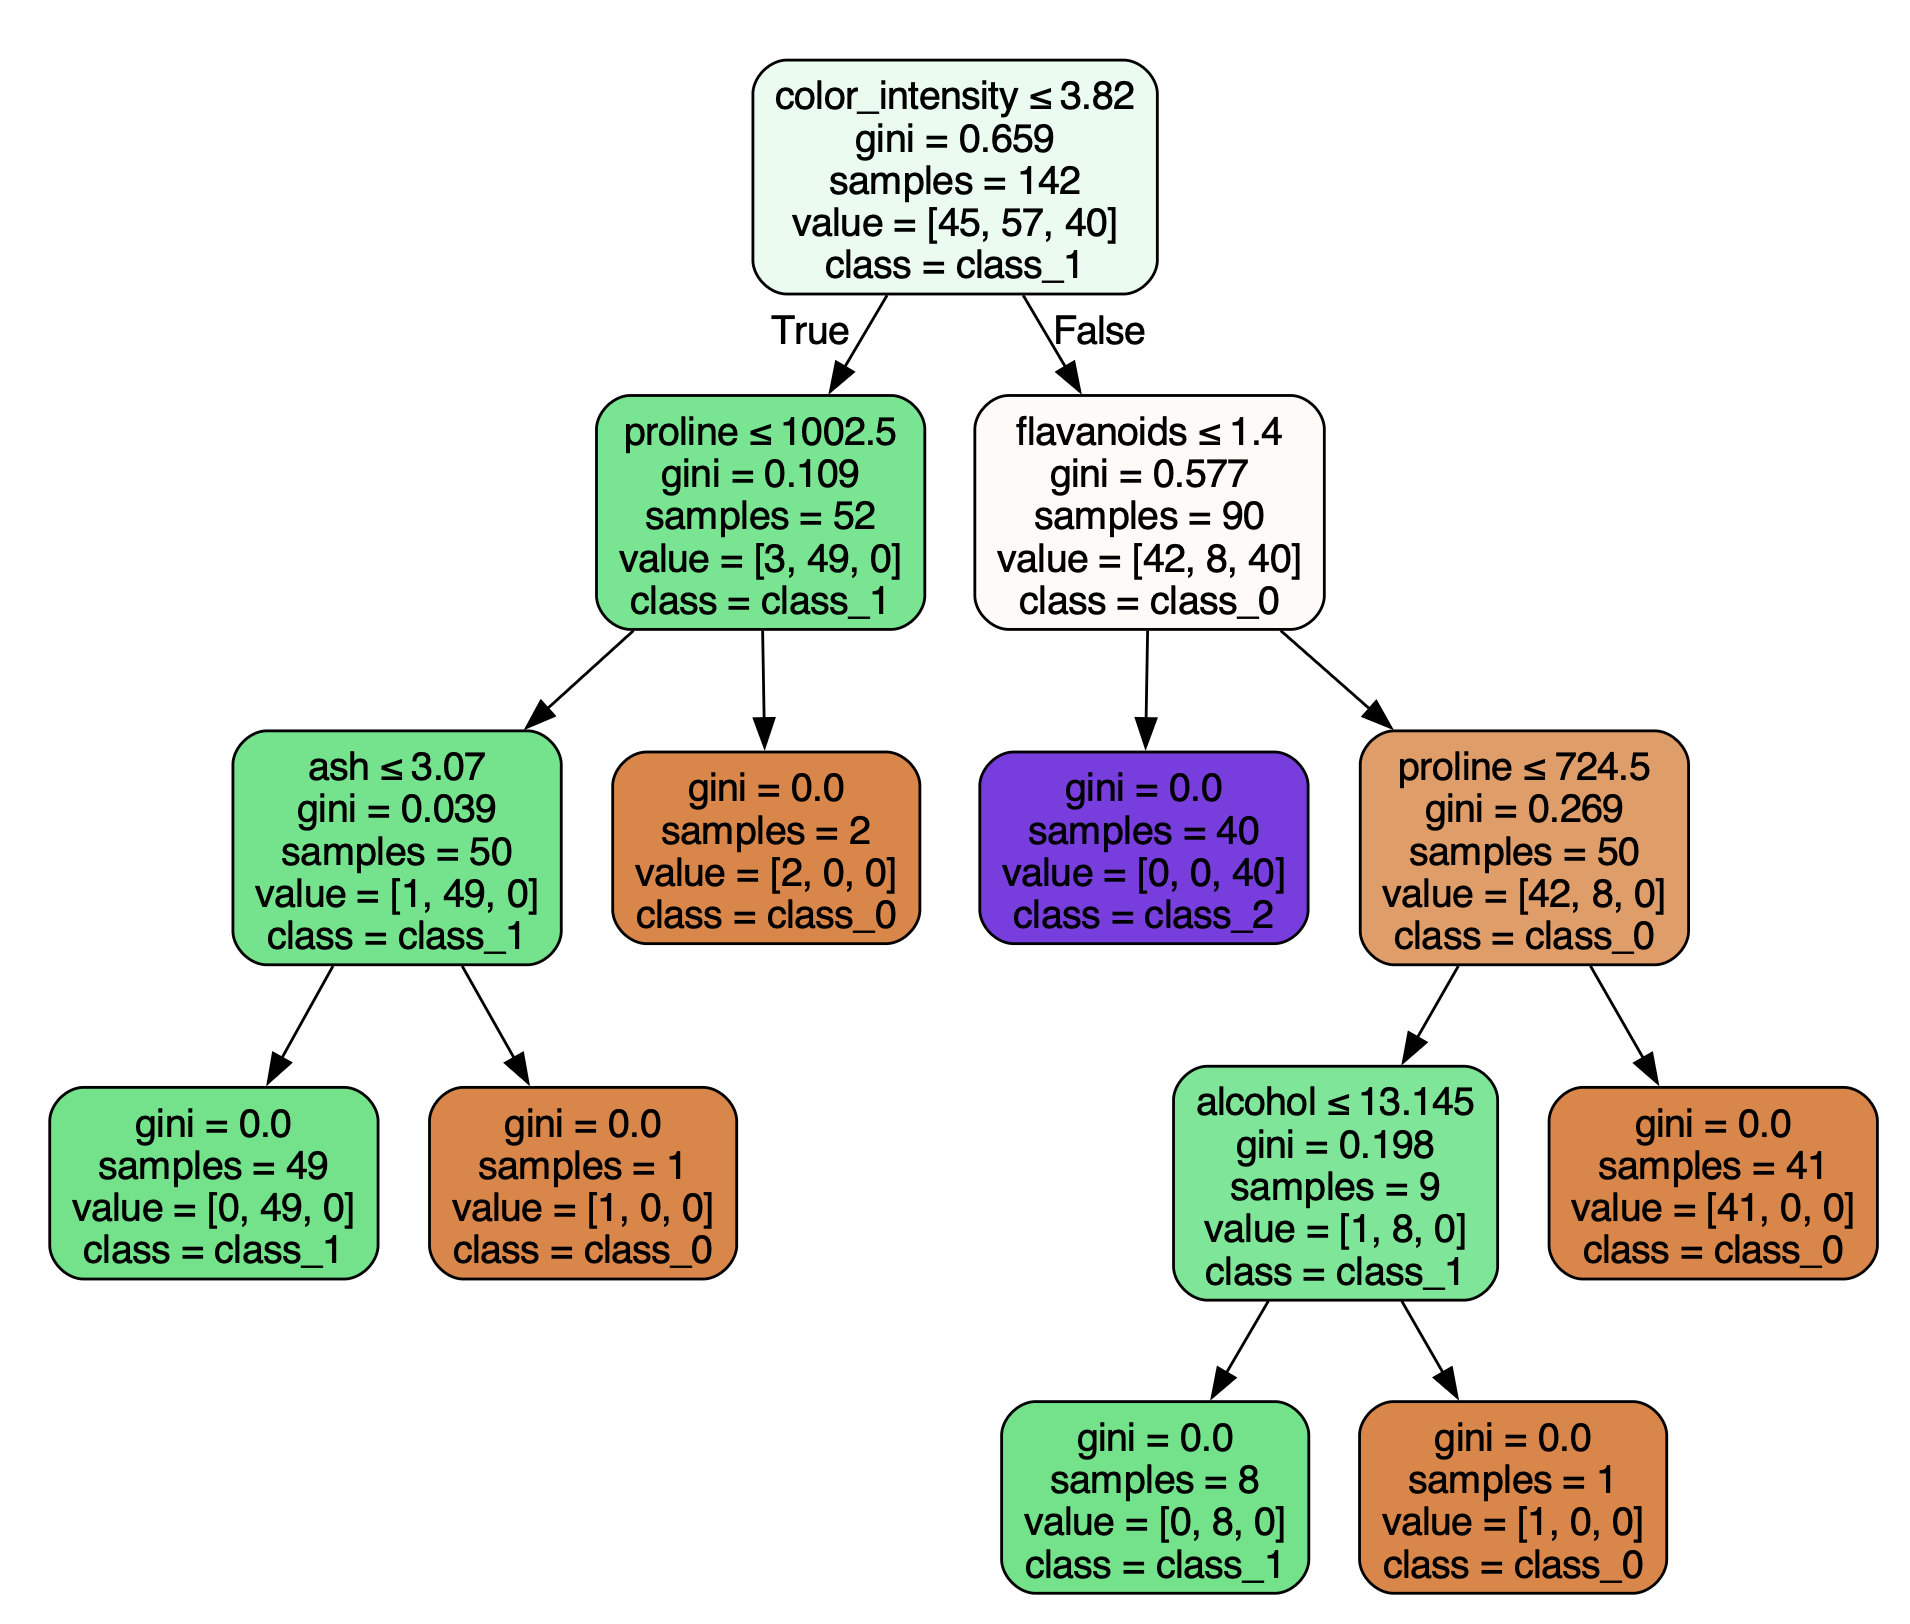

# SO FRICKING COOL!!

After you successfully plotted a tree, you can take a closer look at the result and draw some conclusions.  
In particular:  
- what information is contained in each node?
- Take a closer look at the leaf nodes. Based on what you know about overfitting, what can you learn from these nodes?

Given the dataset X, you can get the predictions of the classifier (one for each entry in X) by calling thepredict() of DecisionTreeClassifier. Then,usetheaccuracy_score() function(whichyou can import from sklearn.metrics) to compute the accuracy between two lists of values (y_true, the list of “correct” labels, and y_pred, the list of predictions made by the classifier). Since you already have both these lists (y for the ground truth, and the result of the predict() method for the prediction), you can already compute the accuracy of your classifier.
> Already done this :)
> #### NO DUMBASS, LEARN HOW TO READ, YOU WERE SUPPOSED TO PREDICT ON THE TRAINING DATA!!!

- What result do you get?
- Does this result seem particularly high/low? Why do you think that is?

In [ ]:
dataset = load_wine ()
x = dataset["data"]             # ARRAY of lists (numbers)
y = dataset["target"]           # ARRAY (0,1,2 I think they correspond to classes)
feature_names = dataset ["feature_names"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

clf = DecisionTreeClassifier()

clf.fit(x_train, y_train)

# PREDICT THE TRAINING DATA --> WHICH IS DUMB AND USELESS BECAUSE THE MODEL IS LITERALLY TRAINED ON THIS DATA, NO SHIT THAT IT WILL PREDICT THE RIGHT CLASSES 100%
predictions = clf.predict(x_train)

training_predictions = clf.predict(x_train)
training_accuracy = accuracy_score(y_train, training_predictions)
print(f"TRAINING accuracy of the model: {training_accuracy}")

print('--------------------------------------------------------------------------------------------------------------')

# ACTUAL PREDICTIONS, USING THE TEST DATA --> this is the real stuff
test_predictions = clf.predict(x_test)
test_accuracy = accuracy_score(y_test, test_predictions)
print(f"TEST accuracy of the model: {test_accuracy}")

# plot the decision tree
dot_data = export_graphviz(clf, out_file=None, 
                           feature_names = dataset.feature_names,
                           class_names= dataset.target_names,
                           filled=True, rounded=True,  
                           special_characters=True)

# Use Graphviz to visualize the tree
graph = graphviz.Source(dot_data)  
graph.render("decision_tree", format="png")  # Saves the visualization as a PNG file
graph.view()  # Opens the image using the default viewer

## The training accuracy (the accuracy computed on the training point) is very high
- Yeah no shit smartass, you're training a model by showing him some training data and the corresponding class
- Then to test it you show the same data you used to train it and ask "what's the corresponding class?" Of course it will guess it, you trained it on that data! No shit you'll get 100% accuracy.

> This is why training accuracy is useless
> We care about the test accuracy!

In [ ]:
print(test_accuracy)

This result is VERY high.  

> Does this result seem particularly high/low? Why do you think that is?
It might be because of overfitting, let's see in general the red flags that suggests it:
- compute training accuracy and test accuracy, if training accuracy is very high and test accuracy very low --> overfitting
- Difference between training accuracy and test accuracy:
```python
# Predict on the training set
train_predictions = clf.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
```
- training accuracy: you feed the model the training points (the points on which the model trained on) and try to predict their class. Then compare the predicted class for the training points and their actual class. This values in general should be high.
```python
# Predict on the test set
test_predictions = clf.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
```
- test accurcy: you feed the model new points (test points) that the model has never seen, try to predict their class and compare to their actual class that the model doesn't know.

- the tree has many leaves --> finding very specific splitting criteria perfectly designed to fit the training set (like splitting on exactly 3.51342633700001) --> overfitting

- High accuracy on training data but low accuracy on test data: A model that performs well on the training set but poorly on the test set is a classic sign of overfitting. The model has essentially “memorized” the training data, and while it may classify that data perfectly, it struggles to generalize to new, unseen data. For example, in the case of a decision tree, we may observe 100% accuracy on the training set but a significantly lower accuracy on the test set.
	
- Complexity of the model: Overfitting often occurs when the model is too complex relative to the underlying patterns in the data. In decision trees, this might manifest as very deep trees with numerous nodes, some of which may represent trivial splits that are unlikely to be relevant for making predictions on new data. This complexity can lead to very small leaf nodes with just a few samples, which makes the model overly sensitive to the noise in the training data.

- Very low Gini values in leaf nodes: In decision trees, Gini values that approach 0 in leaf nodes (which means perfect classification) often indicate overfitting, especially when paired with small sample sizes in those leaves. For example, if a leaf node only contains a single sample but is perfectly classified, it suggests the tree has learned the specific characteristics of that single data point rather than a generalizable rule.

# Is it overfitting??
Meh, maybe?? 🤷🏻‍♂️🤷🏻‍♂️🤷🏻‍♂️
> The Gini index with value completely zero is a BAD signal ...

---

#### 5. Now, we can split our dataset into a training set and a test set. We will use the training set to train a model, and to assess its performance with the test set. Sklearn offers the train_test_split() function to split any number of arrays (all having the same length on the first dimension) into two sets. You can refer to the official documentation to understand how it can be used. You can use an 80/20train/testsplit. Ifusedcorrectly,youwillget4arrays: X_train, X_test, y_train, y_test.

### Now, train a new model using (X_train, y_train). Then, compute the accuracy with (X_test,y_test).
- How does this value compare to the previously computed one?
- Is this a more reasonable value? Why?

## This should give you a good idea as to why training and testing on the same dataset returns meaningless results!!!

> already done this :)


> # You can also compute other metrics (e.g. precision, recall, F1 score) using the respective functions:
- **precision_score**: this is the ratio of correctly predicted positive observations to the total predicted positives. High precision means fewer false positives.

$Precision = \frac{True Positives}{True Positives + False Positives}$

$\frac{TrueCats}{TrueCats + DogsThatIMisclassifiedAsCats}$
 

- **recall_score** (Sensitivity): this is the ratio of correctly predicted positive observations to all observations in the actual class. High recall means fewer false negatives.

$Recall = \frac{True Positives}{True Positives + False Negatives}$

$\frac{TrueCats}{TrueCats + TrueCatsThatIMisclassifiedAsDogs}$

- **f1_score**: This is the weighted average of precision and recall. It tries to balance both precision and recall. The best F1 score is 1, and the worst is 0.

$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$


Note that, since these three metrics are all based on a single class, you can either:
- compute the value for a single class,
- aggregate the results into a single value,
- or receive the results for all three classes.

Check the average parameter on the documentation to learn more about this. You can also use the **classification_report function**, which returns various metrics (including the previously mentioned ones) for each of the classes of the problem.

In [ ]:
dataset = load_wine ()
x = dataset["data"]             # ARRAY of lists (numbers)
y = dataset["target"]           # ARRAY (0,1,2 I think they correspond to classes)
feature_names = dataset ["feature_names"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

clf = DecisionTreeClassifier()

clf.fit(x_train, y_train)

# ACTUAL PREDICTIONS, USING THE TEST DATA --> this is the real stuff
predictions = clf.predict(x_test)

############################################################################################################################################################################################################
###################################################### EVALUATION TOOLS ######################################################################################################
############################################################################################################################################################################################################

# precision PER CLASS
precision = precision_score(predictions, y_test, average=None)
print(f"Precision per class: {precision}")

# recall PER CLASS
recall = recall_score(predictions, y_test, average=None)
print(f"Recall per class: {recall}")

# F1 score PER CLASS
F1_score = f1_score(predictions, y_test, average=None)
print(f"F1 score per class: {F1_score}")

############################################################################################################################################################################################################
# AGGREGATE VALUE: NOT PER CLASS, BUT JUST A UNIQUE VALUE
precision = precision_score(predictions, y_test, average='macro')
print(f"Precision in general: {precision}")

# recall PER CLASS
recall = recall_score(predictions, y_test, average='macro')
print(f"Recall in general: {recall}")

# F1 score PER CLASS
F1_score = f1_score(predictions, y_test, average='macro')
print(f"F1 score in general: {F1_score}")


########################################################################################### very useful
# classification report
CR = classification_report(predictions, y_test)
print('\nClassification Report:')
print(CR)

---

> # 7.
> #### So far, you have only used “default” decision trees (i.e. decision trees using the default configuration).
> The “default” decision tree might not be the best option in terms of performance to fit our dataset.

> In this exercise, you will perform a **“grid search”**:
- You will define a set of possible configurations and, for each configuration, build a classifier.
- Then, you will test the performance of each classifier and identify that configuration that produces the best model.

> #### On the official documentation for Decision Tree Classifier you can find a list of all parameters you can modify.
Here they are:
```python
class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
```
Let's explain them and understand if they might be useful or not
- criterion : {“gini”, “entropy”, “log_loss”}, default=”gini”
    - gini: How mixed the classes are. Lower is better. Fast and works well.
    - entropy: How uncertain the node is. Pure nodes have entropy = 0.
    - log_loss: Produces probabilistic splits, more sensitive to class probabilities; sometimes smoother, but slower

- splitter{“best”, “random”}, default=”best”
    - best: Tries all possible splits and picks the one that maximally reduces impurity.
    - random: Tries a random subset of splits and chooses the best among them.

- max_depth : int, default=None
    - The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure OR until all leaves contain less than min_samples_split samples.

- min_samples_split : int or float, default=2
    - The minimum number of samples required to split an internal node:
        - If int, then consider min_samples_split as the minimum number.
        - If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split (no idea of why someone would use this).

- min_samples_leaf : int or float, default=1
    - The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression --> in dumb words: **Don’t allow tiny leaves. Forces the tree to generalize instead of memorizing single points --> preventing weird, hyper-specific branches.**

- random_state: int, RandomState instance or None, default=None
    - Controls the randomness of the estimator. The features are always randomly permuted at each split, even if splitter is set to "best". When max_features < n_features, the algorithm will select max_features at random at each split before finding the best split among them. But the best found split may vary across different runs, even if max_features=n_features. That is the case, if the improvement of the criterion is identical for several splits and one split has to be selected at random. To obtain a deterministic behaviour during fitting, random_state has to be fixed to an integer --> in dumb words: Set this if you want the exact same tree every time. If you don’t set it, each training run can build a slightly different tree.

- max_leaf_nodes : int, default=None
    - Grow a tree with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes --> in dumb words: Limits how many leaf nodes the tree can have --> Cap the number of final decisions the tree can make. Fewer leaves → simpler tree → less overfitting.

- min_impurity_decreasefloat, default=0.0
    - A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
    - A node will only split if the impurity drops at least by this amount --> If the split doesn’t improve the node enough, don’t bother splitting.

> #### Identify some of the parameters that, based on your theoretical knowledge of decision trees, might affect the performance of the tree.

## Let's revise the theoretical knowledge of decision trees: decision trees, theoretical recap
#### 1. What is a Decision Tree classifier?
A decision tree is a non-linear, non-parametric model that recursively splits the dataset into smaller and smaller regions based on feature values.  

- Each internal node = a test (e.g., “alcohol ≤ 12.5?”)
- Each leaf = a prediction (class label)

The algorithm tries to choose the “best” feature and threshold at every split.  

#### 2. How does a Decision Tree choose a split?
It tries to make child nodes as pure as possible.  

Common impurity metrics:  
- Gini impurity (default in sklearn)

$Gini = 1 - \sum_{k} p_k^2$

**Lower = better**  

- Entropy (information gain)

$Entropy = -\sum_{k} p_k \log_2 p_k$

A good split is one that reduces impurity the most.  

#### 3. Why do trees overfit?
Trees have very low bias and very high variance. They tend to easily overfit.

A fully grown tree (no limits) will:  
- Keep splitting until each leaf is pure
- Often end with leaves containing 1 sample
- Memorize the training data

> Training accuracy = 100%
> Test accuracy = worse, unstable under noise
> ** --> That’s why decision trees need regularization.**

#### 4. Key Hyperparameters (the ones you will tune)
These directly influence performance and overfitting:

> ① max_depth  
**Most important control.**  
Limits how deep the tree can grow.  
- low max_depth → high bias (simple model)
- high max_depth → high variance (complex model) --> if too long = overfitting  
Typical values to test: None, 2, 4, 6, 8, 12

> ② min_samples_split
Minimum number of samples needed to attempt a split.
- Small → many splits → overfitting
- Large → fewer splits → underfitting
Try: 2, 5, 10, 20

> ③ min_samples_leaf
Minimum number of samples required in each leaf.
- Forces leaves to contain more data
- Smooths the model
Try: 1, 2, 5, 10

> ④ criterion
Impurity metric.
- “gini” (default)
- “entropy”
Try both.

> ⑤ splitter
How the best split is chosen:
- “best” → tries all possible splits
- “random” → tries a random subset → higher variance, lower computation, sometimes better on noise
Try: “best”, “random”

> #### 6. Why Grid Search Makes Sense? Why do we grid search?
Because:
- **Trees are extremely sensitive to hyperparameters**
- **The default tree grows very deep → often overfits**
- **You need to test many configurations and compare test accuracy**

#### 7. What to expect on the wine dataset
Decision trees usually:
- reach training accuracy = 100%
- reach test accuracy between 80% and 95% depending on depth

> A deeper tree memorizes the dataset.
> A shallower tree generalizes better.

> For each of these parameters, define a set of possible values (the official documentation provides additional information about the possible values that can be used). For example, we can identify these two parameters:

- max_depth, which defines the maximum depth of the decision tree, can be set to None (i.e. unbounded depth), or to values such as 2, 4, 8 

- splitter, which can be set to either best (in which case, for each split, the algorithm will try all possible splits), or random (in this case, the algorithm will try N random splits on various features and select the best one)

You can and should identify additional parameters and possible values for them.  
Then, you can build a parameter dictionary (i.e. a dictionary where keys are parameter names and values are lists of candidate values).
- Using the **ParameterGrid** class offered by scikit-learn, you can generate a list of all possible configurations that can be obtained from the parameter dictionary.

EXAMPLE:  
```python
from sklearn.model_selection import ParameterGrid
params = {
    " max_depth " : [ None , 2 , 4 , 8] ,
    " splitter " : [ " best "," random " ]
    }

for config in ParameterGrid ( params ):
    print ( config )
```

---

# NICE, after all these info we can do the quest: perform a grid search = fuck around with the tree classifier and find good parameters
> Aim for 100% train accuracy

> Aim for 70-90% test accuracy

> ALWAYS be aware to NOT overfit

In [ ]:
hyperparameters = {
    'max_depth' : [None, 2, 4, 8],
    'splitter' : ['best', 'random'],
    'criterion' : ['gini', 'entropy'],
    'min_samples_split' : [2, 4, 6, 10],
    'min_samples_leaf' : [1, 10],
    # 'max_leaf_nodes': [None, 5, 10]
}

for config in ParameterGrid(hyperparameters):               # list of dictionaries --> config = {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
    print(f"Parameter configuration: {config}")
    
    clf = DecisionTreeClassifier(**config)                  # DecisionTreeClassifier(config) CANNOT WORK as it's a whole dictionary, you have to use UNPACKING ** --> spreads the dictionary into multiple named parameters    
    clf.fit(x_train, y_train)
    predictions = clf.predict(x_test)
    accuracy = accuracy_score(y_test, predictions)


# Problem: for each configuration I want to compute the accuracy
# I need to 'connect' configuration and accuracy so that I can pick the best accuracy and find the corresponding configuration

In [ ]:
# hyperparametrs tuning --> COMBINATIONS
hyperparameters = {
    'max_depth' : [None, 2, 4, 8],
    'splitter' : ['best', 'random'],
    'criterion' : ['gini', 'entropy'],
    'min_samples_split' : [2, 4, 6, 10],
    'min_samples_leaf' : [1, 10],
    'max_leaf_nodes': [None, 5, 10]
}

option_1 = False
if option_1:
    accuracy_results = []
    configurations = []
    for config in ParameterGrid(hyperparameters):
        # print(f"Parameter configuration: {config}") 
        clf = DecisionTreeClassifier(**config)                  # DecisionTreeClassifier(config) CANNOT WORK as it's a dictionary, you have to use UNPACKING ** --> spreads the dictionary into multiple named parameters
        
        clf.fit(x_train, y_train)
        predictions = clf.predict(x_test)

        accuracy = accuracy_score(y_test, predictions)

        accuracy_results.append(accuracy)
        configurations.append(config)

    accuracy_results = np.array(accuracy_results)
    configurations = np.array(configurations)

    sorted_idx = np.argsort(accuracy_results)[::-1]

    sorted_accuracy = accuracy_results[sorted_idx]
    sorted_configurations = configurations[sorted_idx]
    for idx in range(len(sorted_configurations)):
        print(f"The accuracy {sorted_accuracy[idx]} was obtained with the following configuration: {sorted_configurations[idx]}")


# create the 'pair' accuracy - configuration --> tuples
option_2 = True
if option_2:
    results = []   # list of tuples (accuracy, config)

    for config in ParameterGrid(hyperparameters):
        clf = DecisionTreeClassifier(random_state=42, **config)
        clf.fit(x_train, y_train)
        acc = accuracy_score(y_test, clf.predict(x_test))

        results.append((acc, config))
    
    results_sorted = sorted(results, key=lambda x: x[0], reverse=True)
    best_tree_model = results_sorted[0]
    print(best_tree_model)



### If I add 'random_state=42' is it as if I'm removing 'splitter='random''?

#### splitter='random'
> Randomness in how splits are chosen  

Imagine you have this tiny dataset:  
```text
feature     label
1.0         0
2.0         0
9.0         1
10.0        1
```

- A “normal” tree (splitter='best') evaluates all possible splits, chooses the one with highest information gain.
- But with splitter='random', the tree randomly chooses one candidate feature/split at each node.
- So:

> Run 1
The randomness picks split → “feature ≤ 2.5?”
Tree becomes:  

    - left: class 0
    
    - right: class 1

Perfectly pure → high accuracy.  

> Run 2
The randomness picks split: → “feature ≤ 9.5?”
Tree becomes:

    - left: [1,2,9] (labels 0,0,1) → mixed
    
    - right: [10] (label 1)

Worse split → worse accuracy.  

> Same data, same model, different random split chosen → different tree.

#### random_state=42
> Freezes the randomness → repeatability

Let’s repeat the previous scenario:  
```python
clf = DecisionTreeClassifier(splitter='random')
```

Without random_state:  
- Run 1 → random split might be “feature ≤ 2.5?”
- Run 2 → random split might be “feature ≤ 9.5?”

The trees differ → accuracy differs → grid search becomes noisy.  

> With random_state=42:
```python
clf = DecisionTreeClassifier(splitter='random', random_state=42)
```

Now every time you run the script, the internal random number generator produces the same sequence, so:  
- Run 1 → tree uses random split X
- Run 2 → again the same random split X
- Run 3 → again the same random split X

> You still have randomness, but now it is deterministic/FIXED randomness.
- splitter='random' → the algorithm uses randomness to choose splits.
- random_state=42 → the algorithm repeats the same random choices every run, so experiments are reproducible.

# What we referred to as “parameters” typically goes by the name of **“hyperparameters”**. These are parameters that are set before the training of the model. A model’s **“parameters”**, instead, are those value that are learned during the training phase (for a decision tree, for example, the features to split and the threshold values for the splits are parameters).

In [ ]:
# best tree model
print(best_tree_model)
# are you fucking kidding me?
# that is exactly the default DecisionTreeClassifier configuration

hyperparameters = {
    'criterion' : 'gini',
    'max_depth' : None,
    'min_samples_leaf' : 1,
    'min_samples_split' : 2,
    'splitter' : 'best',
    'random_state' : 42
}

clf = DecisionTreeClassifier(**hyperparameters)
clf.fit(x_train, y_train)
predictions = clf.predict(x_test)

---

> # 8. In the previous exercise, you searched for the best configuration among a list of possible alternatives.
# PROBLEM: Since we used our test data to select the model, you may be overfitting on the test data (you may have selected the configuration that works best for the test set, but which may not be as good on new data).

# Typically, you **do not want** to use the **test set for tuning the model’s hyperparameters**, since the test set should **only** be used as a **final evaluation** --> **VALIDATION SET**

For this reason, datasets are typically splitted into
- Training set: used to create the model.
- **Validation set**: used to assess how good each configuration of a classifier is.
- Test set: used at the end of the hyperparameter tuning, to assess how good our final model is.

### However,it often happens that only a limited amount of data is available. In these cases, it is wasteful to only use a small fraction of the dataset for the actual training
# --> **cross-validation**
- In these cases, cross-validation can be used to “get rid” of the validation set. You can read more about cross-validation on the course slides --> Let's see:

#### Hold-Out Validation
The **hold-out** method is the simplest way to evaluate a model.

You split your dataset into two parts:

- **Training set** → used to fit the model  
- **Test set** → used to evaluate the model  
Example: 80% train, 20% test.

**Pros:** simple, fast  
**Cons:** the result depends heavily on *which* random split you get.  
Different splits → different accuracy.

#### **Cross-Validation**  
Cross-validation fixes the randomness problem in hold-out.

You divide the data into **k folds** (e.g., k = 5):  
1. Train on 4 folds, test on the remaining 1  
2. Repeat 5 times (each fold becomes the test fold once)  
3. Average the 5 scores  

This gives a **stable, reliable** estimate of model performance.

**Pros:** less variance, uses all data  
**Cons:** slower (model is trained k times)

# k-fold cross-validation
One popular method of is the **k-fold cross-validation**. In this, the training set is split into k partitions. k−1 are used for the training the other one is used validation. This is repeated until all partitions have been used once for validation.

```python
from sklearn.model_selection import KFold

# Split the datasets into two:
#- X_train_valid: the dataset used for the k-fold cross-validation
#- X_test: the dataset used for the final testing (this will NOT be seen by the classifier during the training/validation phases)
X_train_valid, X_test, y_train_valid, y_test = train test_split (...)
kf = KFold (5) # 5-fold cross-validation

# X and y are the arrays to be split
for train_indices, validation_indices in kf.split(X_train_valid):
    X_train = X_train_valid[train_indices]
    X_valid = X_train_valid[validation_indices]
    y_train = y_train_valid[train_indices]
    y_valid = y train_valid[validation_indices]
```

> Notice that kf.split() returns a list of tuples, where the first value of each tuple are the indices that should be used for training, the second are the indices used for validation.

Then, since X and y are NumPy arrays, we can extract the values we are interested in with fancy indexing (why???).

> For each fold, you can use the **training data** (i.e. X_train in the example above) to **train each classifier** (i.e. decision trees with different configurations) and **measure the performance** on the **validation data** (i.e. X_valid).  

> You can then aggregate the information extracted (e.g. by computing the overall accuracy from the accuracies on each fold) and **select the best performing model ON VALIDATION DATA**.
> **After you select one model**, you can assess its **performance** on **never-before-seen data** (i.e. your **test set**).

- split data into train + evaluation (k-means cross validation) and test data
- set up a grid search for the tree hyperparameters
- do this for every tree model:
    - iteration 1: run the tree #1 on train data and make it predict the validation data
    - sliding window, change the training data and validation data
    - iteration 2: run the tree #1 on the new train data and make it predict the new validation data
    - iterate until all data had become evaluation data and had been predicted
    - then move on tree #2 and do the same.
- pick the best model
- feed him never-seen data : the test data

So, since K=5, I'll compute 5 accuracis for each tree --> do the average

# The data management is hard AF in this ex

In [ ]:
# split the data as before: 
# 80% of data = train + validation : goes into X_train_valid and will be used in the k-fold loop
# 20 % of data = test : goes into X_test

x_train_valid, x_test, y_train_valid, y_test = train_test_split (x,y, test_size=0.2, random_state = 42)
kf = KFold (n_splits=5, shuffle=True, random_state=42)      # 5-fold cross-validation

hyperparameters = {
    'max_depth' : [None, 2, 4, 8],
    'splitter' : ['best', 'random'],
    'criterion' : ['gini', 'entropy'],
    'min_samples_split' : [2, 4, 6, 10],
    'min_samples_leaf' : [1, 10],
    'max_leaf_nodes': [None, 5, 10],
    'random_state' : [42]
    }


results = {}
for config in ParameterGrid(hyperparameters):
    key = tuple(sorted(config.items()))   # (('criterion', 'gini'), ('splitter', 'best'), ...) : [], (('criterion', 'entropy'), ('splitter' ....
    results[key] = []


for train_indices, validation_indices in kf.split(x_train_valid):

    # 1. Extract training fold
    x_train = x_train_valid[train_indices]
    x_valid = x_train_valid[validation_indices]
    
    # 2. Extract validation fold
    y_train = y_train_valid[train_indices]
    y_valid = y_train_valid[validation_indices]

    for config in ParameterGrid(hyperparameters):
        clf = DecisionTreeClassifier(**config)

        clf.fit(x_train, y_train)
        predictions = clf.predict(x_valid)
        accuracy = accuracy_score(y_valid, predictions)
        
        key = tuple(sorted(config.items()))
        results[key].append(float(accuracy))

# print(results)
# {
#   (('criterion', 'gini'), ('max_depth', None), ('max_leaf_nodes', None), ('min_samples_leaf', 1), ('min_samples_split', 2), ('splitter', 'best')): [0.896551724137931, 1.0, 0.7857142857142857, 0.9285714285714286, 0.9642857142857143]
#   ,
#   (('criterion', 'gini'), ('max_depth', None), ('max_leaf_nodes', None), ('min_samples_leaf', 1), ('min_samples_split', 2), ('splitter', 'random')): [0.896551724137931, 0.9310344827586207, 0.9285714285714286, 0.9642857142857143, 0.9285714285714286],
#   ...
# }

# compute the mean accuracy per configuration
for config in results:
    results[config] = np.mean(results[config])

# sort based on accuracy --> argsort
# sorted(results.items(), key = lambda x:x[1], reverse=True)    --> AVOID IT AS IT ADDS ANOTHER TUPLE ((())), hell nah
conf_keys = list(results.keys())
acc_vals = np.array(list(results.values()))

sorted_idx = np.argsort(acc_vals)[::-1]

for rank, idx in enumerate(sorted_idx):
    print(f"Position: {rank + 1}, \nAccuracy: {acc_vals[idx]}, \nConfiguration: {conf_keys[idx]}")
    print()






# Best performing model on the evaluation set using k-fold cross validation
```python
Position: 1, 
Accuracy: 0.9224137931034484, 
Configuration: (('criterion', 'entropy'), ('max_depth', 8), ('max_leaf_nodes', 10), ('min_samples_leaf', 1), ('min_samples_split', 2), ('random_state', 42), ('splitter', 'best'))
```

## Now let's test it on the test set
- create a new tree with the best hyperparameters found
- train it on train + evaluation data (80% dataset)
- test it on the test data
- compute accuracy

In [ ]:
best_config = {
    'criterion' : 'entropy',
    'max_depth' : 8,
    'max_leaf_nodes' : 10,
    'min_samples_leaf' : 1,
    'min_samples_split' : 2,
    'splitter' : 'best',
    'random_state' : 42
}

final_clf = DecisionTreeClassifier(**best_config)
final_clf.fit(x_train_valid, y_train_valid)
predictions = final_clf.predict(x_test)
accuracy = accuracy_score(y_test, predictions)

print(f"The accuracy of the best model found is: {accuracy}")

#### 9. (*) Given a decision tree, we can assign an importance to each split of the tree. The importance of a split can be computed as the decrease in impurity achieved by it

# HELL NAH